## Exploratory Data Analysis (EDA) Objective

The goal of exploratory data analysis (EDA) is to understand the structure,
distribution, and relationships within the data before modeling.

In this project, EDA is performed to:
- Understand the distribution of the target variable (`loan_condition`)
- Analyze key numerical and categorical features
- Identify patterns related to loan default
- Detect missing values and outliers
- Generate insights that guide feature engineering and model selection

EDA ensures that modeling decisions are data-driven and aligned with business context.


In [34]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Load cleaned dataset from previous step
df = pd.read_csv("loan_data.csv")

# Drop leakage columns again to ensure clean EDA dataset
leakage_cols = [
    "total_pymnt",
    "total_rec_prncp",
    "recoveries",
    "installment",
    "final_d"
]

df = df.drop(columns=leakage_cols)

# Quick check
df.shape


(887379, 25)

In [35]:
# Dataset structure and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887379 entries, 0 to 887378
Data columns (total 25 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    887379 non-null  int64  
 1   year                  887379 non-null  int64  
 2   issue_d               887379 non-null  object 
 3   emp_length_int        887379 non-null  float64
 4   home_ownership        887379 non-null  object 
 5   home_ownership_cat    887379 non-null  int64  
 6   income_category       887379 non-null  object 
 7   annual_inc            887379 non-null  int64  
 8   income_cat            887379 non-null  int64  
 9   loan_amount           887379 non-null  int64  
 10  term                  887379 non-null  object 
 11  term_cat              887379 non-null  int64  
 12  application_type      887379 non-null  object 
 13  application_type_cat  887379 non-null  int64  
 14  purpose               887379 non-null  object 
 15  

In [36]:
# Target variable distribution (counts)
df["loan_condition"].value_counts()


loan_condition
Good Loan    819950
Bad Loan      67429
Name: count, dtype: int64

In [37]:
# Target distribution in percentage
df['loan_condition'].value_counts(normalize=True) * 100


loan_condition
Good Loan    92.40133
Bad Loan      7.59867
Name: proportion, dtype: float64

### Target Variable Imbalance

The target variable (`loan_condition`) is highly imbalanced:

- Good Loans: ~92.4%
- Bad Loans: ~7.6%

This indicates a strong class imbalance, which is common in real-world credit risk datasets.

#### Why this matters:
- A naive model predicting **only "Good Loan"** would achieve over **92% accuracy**, yet be useless for risk management.
- Accuracy alone is not a reliable evaluation metric in this case.
- The business objective is to correctly identify **Bad Loans**, even if they are rare.

#### Modeling implications:
- Evaluation should focus on metrics such as:
  - Recall (Sensitivity) for Bad Loans
  - Precision–Recall tradeoff
  - ROC-AUC
- Class imbalance handling techniques (e.g., class weights, resampling) may be required later.


In [38]:
# Summary statistics for numerical features
df.describe()

,id,year,emp_length_int,home_ownership_cat,annual_inc,income_cat,loan_amount,term_cat,application_type_cat,purpose_cat,interest_payment_cat,loan_condition_cat,interest_rate,grade_cat,dti
count,8.873790e+05,887379.000000,887379.000000,887379.000000,8.873790e+05,887379.000000,887379.000000,887379.000000,887379.000000,887379.000000,887379.000000,887379.000000,887379.000000,887379.000000,887379.000000
mean,3.246513e+07,2014.021761,6.050564,2.099130,7.502759e+04,1.196702,14755.264605,1.300045,1.000576,4.874621,1.475629,0.075987,13.246740,2.798403,18.157039
std,2.282734e+07,1.261741,3.507405,0.944839,6.469815e+04,0.442542,8435.455601,0.458278,0.023990,2.381156,0.499406,0.264977,4.381867,1.312599,17.190626
min,5.473400e+04,2007.000000,0.500000,1.000000,0.000000e+00,1.000000,500.000000,1.000000,1.000000,1.000000,1.000000,0.000000,5.320000,1.000000,0.000000
25%,9.206643e+06,2013.000000,3.000000,1.000000,4.500000e+04,1.000000,8000.000000,1.000000,1.000000,3.000000,1.000000,0.000000,9.990000,2.000000,11.910000
50%,3.443327e+07,2014.000000,6.050000,3.000000,6.500000e+04,1.000000,13000.000000,1.000000,1.000000,6.000000,1.000000,0.000000,12.990000,3.000000,17.650000
75%,5.490814e+07,2015.000000,10.000000,3.000000,9.000000e+04,1.000000,20000.000000,2.000000,1.000000,6.000000,2.000000,0.000000,16.200000,4.000000,23.950000
max,6.861706e+07,2015.000000,10.000000,6.000000,9.500000e+06,3.000000,35000.000000,2.000000,2.000000,14.000000,2.000000,1.000000,28.990000,7.000000,9999.000000


In [39]:
# Check missing values in each column
df.isnull().sum()


id                      0
year                    0
issue_d                 0
emp_length_int          0
home_ownership          0
home_ownership_cat      0
income_category         0
annual_inc              0
income_cat              0
loan_amount             0
term                    0
term_cat                0
application_type        0
application_type_cat    0
purpose                 0
purpose_cat             0
interest_payments       0
interest_payment_cat    0
loan_condition          0
loan_condition_cat      0
interest_rate           0
grade                   0
grade_cat               0
dti                     0
region                  0
dtype: int64

In [40]:
# Number of unique values in each categorical column
df.select_dtypes(include="object").nunique()


issue_d              103
home_ownership         6
income_category        3
term                   2
application_type       2
purpose               14
interest_payments      2
loan_condition         2
grade                  7
region                 5
dtype: int64

In [41]:
# Summary statistics for numerical features
df.describe()


,id,year,emp_length_int,home_ownership_cat,annual_inc,income_cat,loan_amount,term_cat,application_type_cat,purpose_cat,interest_payment_cat,loan_condition_cat,interest_rate,grade_cat,dti
count,8.873790e+05,887379.000000,887379.000000,887379.000000,8.873790e+05,887379.000000,887379.000000,887379.000000,887379.000000,887379.000000,887379.000000,887379.000000,887379.000000,887379.000000,887379.000000
mean,3.246513e+07,2014.021761,6.050564,2.099130,7.502759e+04,1.196702,14755.264605,1.300045,1.000576,4.874621,1.475629,0.075987,13.246740,2.798403,18.157039
std,2.282734e+07,1.261741,3.507405,0.944839,6.469815e+04,0.442542,8435.455601,0.458278,0.023990,2.381156,0.499406,0.264977,4.381867,1.312599,17.190626
min,5.473400e+04,2007.000000,0.500000,1.000000,0.000000e+00,1.000000,500.000000,1.000000,1.000000,1.000000,1.000000,0.000000,5.320000,1.000000,0.000000
25%,9.206643e+06,2013.000000,3.000000,1.000000,4.500000e+04,1.000000,8000.000000,1.000000,1.000000,3.000000,1.000000,0.000000,9.990000,2.000000,11.910000
50%,3.443327e+07,2014.000000,6.050000,3.000000,6.500000e+04,1.000000,13000.000000,1.000000,1.000000,6.000000,1.000000,0.000000,12.990000,3.000000,17.650000
75%,5.490814e+07,2015.000000,10.000000,3.000000,9.000000e+04,1.000000,20000.000000,2.000000,1.000000,6.000000,2.000000,0.000000,16.200000,4.000000,23.950000
max,6.861706e+07,2015.000000,10.000000,6.000000,9.500000e+06,3.000000,35000.000000,2.000000,2.000000,14.000000,2.000000,1.000000,28.990000,7.000000,9999.000000


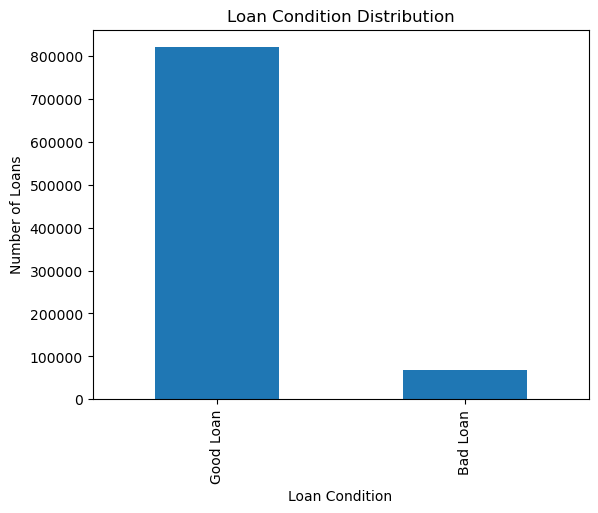

In [42]:
import matplotlib.pyplot as plt

# Plot target distribution
df['loan_condition'].value_counts().plot(kind='bar')
plt.title('Loan Condition Distribution')
plt.xlabel('Loan Condition')
plt.ylabel('Number of Loans')
plt.show()


### Feature Summary & Data Quality Check

After inspecting missing values and summary statistics, the dataset appears to be largely clean:

- No missing values in numerical features
- Very few missing values in selected categorical variables (already identified earlier)
- Numerical features show reasonable ranges and distributions

Key observations:
- Loan amounts are mostly concentrated between 8,000 and 20,000
- Interest rates vary widely, indicating different borrower risk profiles
- Debt-to-income (DTI) shows extreme values (e.g., 9999), which may require attention during preprocessing
- Several categorical variables have already been label-encoded into `_cat` features

This confirms the dataset is suitable for modeling, with minimal preprocessing required beyond:
- Handling extreme / sentinel values
- Addressing class imbalance
- Feature scaling (for selected models)


### Outliers & Special Values

Some features contain extreme or special values that may impact model performance:

- **DTI (Debt-to-Income)** includes very large values (e.g., 9999), which likely represent missing or undefined cases rather than real financial ratios
- **Annual Income** shows a wide range, with potential high-income outliers
- **Loan Amount** distribution appears right-skewed, which is common in financial datasets

Handling strategy:
- Investigate and cap or remove sentinel values (e.g., DTI = 9999)
- Consider log transformation for highly skewed variables such as `annual_inc`
- Use robust models or scaling techniques to reduce sensitivity to outliers

These steps will help stabilize training and improve generalization.


### Categorical Variable Overview

The dataset contains several categorical features that have already been encoded into numerical categories:

- `home_ownership_cat`
- `income_cat`
- `term_cat`
- `application_type_cat`
- `purpose_cat`
- `interest_payment_cat`
- `grade_cat`
- `loan_condition_cat` (target)

Why this matters:
- Machine learning models require numerical inputs
- Encoding categorical variables upfront simplifies modeling
- Category encodings preserve ordinal relationships where applicable (e.g., grades)

Important note:
- Original categorical columns are retained mainly for **EDA and interpretability**
- Encoded versions will be used for **model training**


### Numerical Feature Overview

Key numerical variables in the dataset include:

- `annual_inc`
- `loan_amount`
- `interest_rate`
- `dti`
- `emp_length_int`

Observations from summary statistics:
- Income and loan amounts show **wide ranges**, indicating potential outliers
- `interest_rate` and `dti` are continuous variables with meaningful spread
- `emp_length_int` is bounded and already numerically encoded

Why this matters:
- Numerical features may require **scaling or normalization**
- Outliers can disproportionately affect certain models (e.g., linear models)
- Distribution analysis helps decide whether transformations (e.g., log) are needed

Next steps:
- Visualize distributions of key numerical features
- Compare distributions across loan conditions (Good vs Bad)


### Categorical Feature Overview

The dataset contains several categorical features, many of which have already been label-encoded.
Key categorical variables include:

- `home_ownership`
- `income_category`
- `term`
- `application_type`
- `purpose`
- `grade`
- `region`

Observations:
- Most categorical variables have a **small number of unique classes**
- Encoded versions (`*_cat`) exist alongside original categorical columns
- Some categories (e.g., loan `purpose`) may have uneven frequency distributions

Why this matters:
- Categorical imbalance can influence model bias
- Some models (tree-based) can work directly with encoded categories
- Others may benefit from one-hot encoding or target encoding

Next steps:
- Analyze category frequency distributions
- Examine relationship between key categorical variables and loan condition


### EDA Summary & Transition to Deeper Analysis

At this stage, the exploratory data analysis has established a strong understanding of the dataset:

- The dataset is large, clean, and well-structured
- No missing values are present
- The target variable is highly imbalanced
- Numerical features show outliers and skewness
- Categorical variables have manageable cardinality
- Encoded categorical features are already available for modeling

Key takeaways:
- Class imbalance must be handled carefully during modeling
- Sentinel and extreme values (e.g., DTI = 9999) require preprocessing
- Feature distributions suggest potential transformations and scaling

With this foundation in place, the next phase will focus on:
- Feature–target relationship analysis
- Feature engineering and preprocessing
- Building and evaluating predictive models



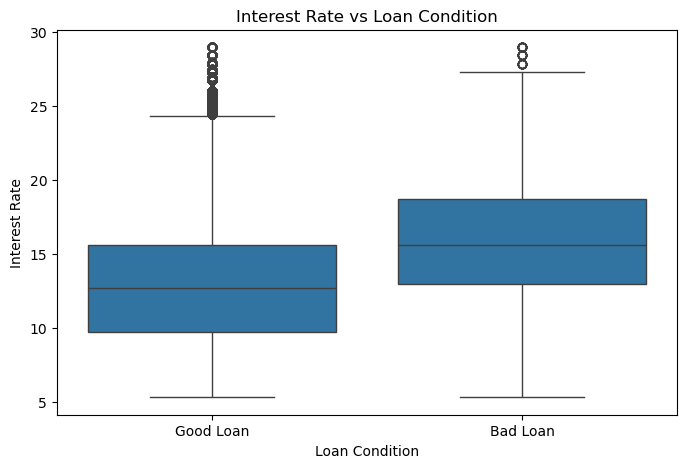

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Interest rate distribution by loan condition
plt.figure(figsize=(8, 5))
sns.boxplot(x="loan_condition", y="interest_rate", data=df)
plt.title("Interest Rate vs Loan Condition")
plt.xlabel("Loan Condition")
plt.ylabel("Interest Rate")
plt.show()


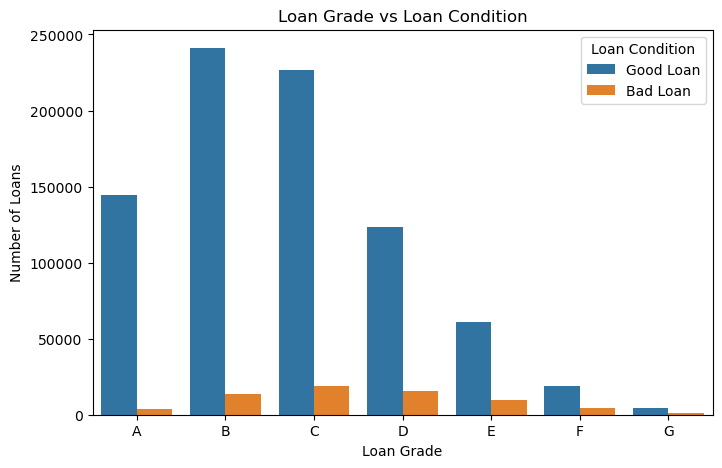

In [44]:
# Loan grade vs loan condition
plt.figure(figsize=(8, 5))
sns.countplot(
    x="grade",
    hue="loan_condition",
    data=df,
    order=sorted(df["grade"].unique())
)
plt.title("Loan Grade vs Loan Condition")
plt.xlabel("Loan Grade")
plt.ylabel("Number of Loans")
plt.legend(title="Loan Condition")
plt.show()


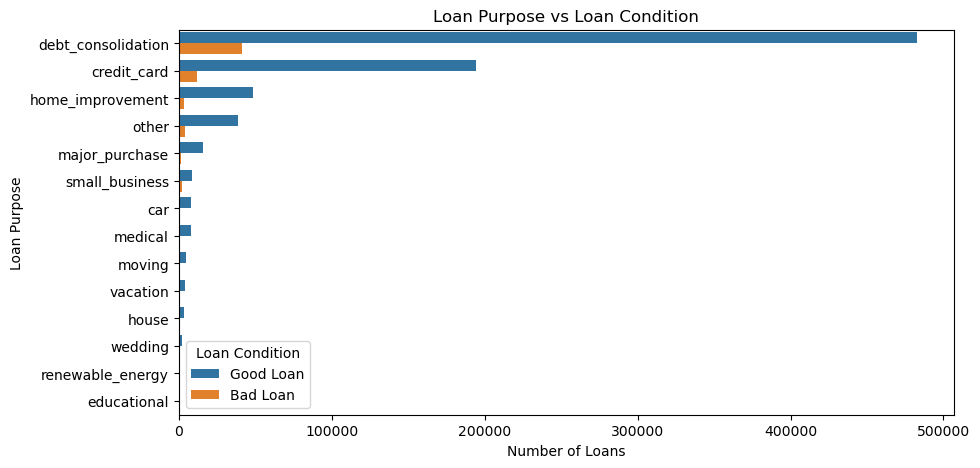

In [45]:
# Loan purpose vs loan condition
plt.figure(figsize=(10, 5))
sns.countplot(
    y="purpose",
    hue="loan_condition",
    data=df,
    order=df["purpose"].value_counts().index
)
plt.title("Loan Purpose vs Loan Condition")
plt.xlabel("Number of Loans")
plt.ylabel("Loan Purpose")
plt.legend(title="Loan Condition")
plt.show()


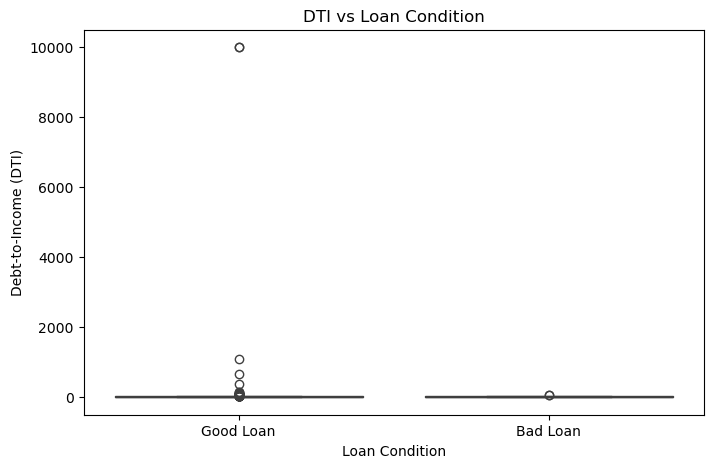

In [46]:
# DTI distribution by loan condition
plt.figure(figsize=(8, 5))
sns.boxplot(x="loan_condition", y="dti", data=df)
plt.title("DTI vs Loan Condition")
plt.xlabel("Loan Condition")
plt.ylabel("Debt-to-Income (DTI)")
plt.show()


In [47]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Summary statistics
df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
id,887379.0,3.246513e+07,2.282734e+07,54734.00,9206643.00,34433267.00,54908135.00,68617057.00
year,887379.0,2.014022e+03,1.261741e+00,2007.00,2013.00,2014.00,2015.00,2015.00
emp_length_int,887379.0,6.050564e+00,3.507405e+00,0.50,3.00,6.05,10.00,10.00
home_ownership_cat,887379.0,2.099130e+00,9.448385e-01,1.00,1.00,3.00,3.00,6.00
annual_inc,887379.0,7.502759e+04,6.469815e+04,0.00,45000.00,65000.00,90000.00,9500000.00
income_cat,887379.0,1.196702e+00,4.425417e-01,1.00,1.00,1.00,1.00,3.00
loan_amount,887379.0,1.475526e+04,8.435456e+03,500.00,8000.00,13000.00,20000.00,35000.00
term_cat,887379.0,1.300045e+00,4.582776e-01,1.00,1.00,1.00,2.00,2.00
application_type_cat,887379.0,1.000576e+00,2.399004e-02,1.00,1.00,1.00,1.00,2.00
purpose_cat,887379.0,4.874621e+00,2.381156e+00,1.00,3.00,6.00,6.00,14.00


In [48]:
# Categorical columns
categorical_cols = df.select_dtypes(include=["object"]).columns

# Display value counts for each categorical feature
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(normalize=True) * 100)



--- issue_d ---
issue_d
01/10/2015    5.480296
01/07/2015    5.179523
01/12/2015    4.996963
01/10/2014    4.370399
01/11/2015    4.229309
                ...   
01/08/2007    0.008339
01/07/2007    0.007100
01/09/2008    0.006423
01/09/2007    0.005973
01/06/2007    0.002705
Name: proportion, Length: 103, dtype: float64

--- home_ownership ---
home_ownership
MORTGAGE    49.985068
RENT        40.131331
OWN          9.857119
OTHER        0.020510
NONE         0.005635
ANY          0.000338
Name: proportion, dtype: float64

--- income_category ---
income_category
Low       82.221463
Medium    15.886898
High       1.891638
Name: proportion, dtype: float64

--- term ---
term
36 months    69.995459
60 months    30.004541
Name: proportion, dtype: float64

--- application_type ---
application_type
INDIVIDUAL    99.942415
JOINT          0.057585
Name: proportion, dtype: float64

--- purpose ---
purpose
debt_consolidation    59.074533
credit_card           23.234942
home_improvement       5.84

## Visual Exploratory Data Analysis (EDA)

In this section, we visually explore relationships between features and the target variable (`loan_condition`).

The goal is to:
- Identify strong predictors
- Detect patterns and anomalies
- Build intuition before modeling


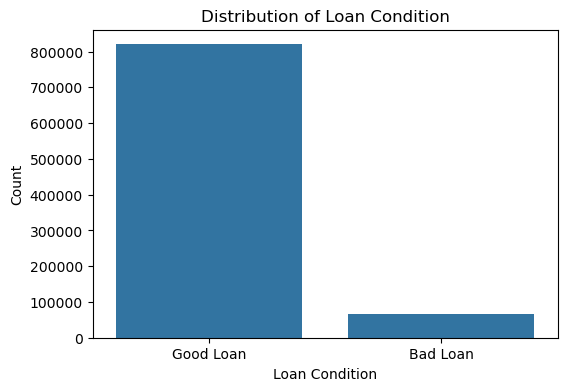

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="loan_condition")
plt.title("Distribution of Loan Condition")
plt.xlabel("Loan Condition")
plt.ylabel("Count")
plt.show()


## Numerical Features vs Target

We now analyze how key numerical variables differ between **Good Loans** and **Bad Loans**.

Goal:
- Identify variables that show **clear separation** between classes
- These variables are strong candidates for modeling

We start with **interest_rate**, which is intuitively one of the most important risk indicators.


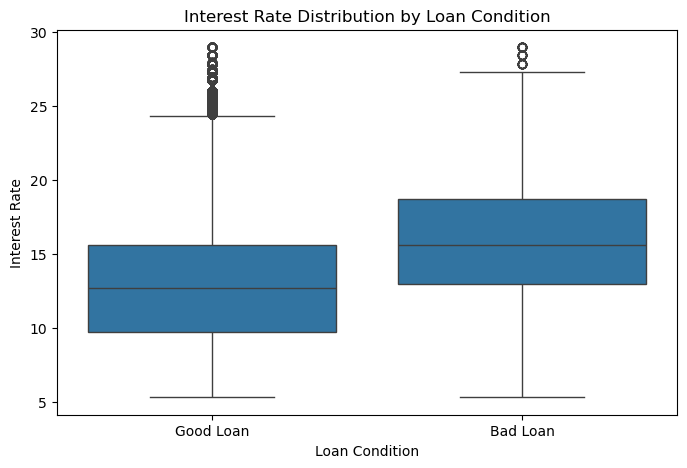

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(
    x="loan_condition",
    y="interest_rate",
    data=df
)
plt.title("Interest Rate Distribution by Loan Condition")
plt.xlabel("Loan Condition")
plt.ylabel("Interest Rate")
plt.show()


### Insight: Interest Rate vs Loan Condition

Observations:
- **Bad Loans** have noticeably **higher median interest rates**
- The distribution for Bad Loans is shifted upward
- There is more variability in interest rates among Bad Loans

Interpretation:
- Higher interest rates reflect **higher perceived borrower risk**
- Lenders charge more interest where default risk is higher

Modeling takeaway:
- `interest_rate` is a **strong predictive feature**
- Expect high importance in tree-based models
- Also useful in linear models due to clear class separation


## Debt-to-Income Ratio (DTI) vs Loan Condition

Debt-to-Income ratio (DTI) measures how much of a borrower’s income is already committed to debt.

Intuition:
- Higher DTI → less disposable income
- Less buffer to handle financial stress
- Higher likelihood of default

We examine how DTI differs between **Good Loans** and **Bad Loans**.


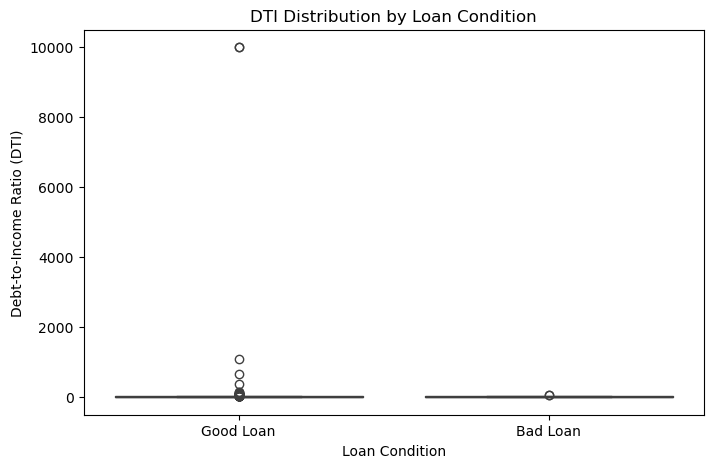

In [51]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="loan_condition",
    y="dti",
    data=df
)
plt.title("DTI Distribution by Loan Condition")
plt.xlabel("Loan Condition")
plt.ylabel("Debt-to-Income Ratio (DTI)")
plt.show()


### Important Observation: Extreme DTI Outliers

The DTI boxplot is heavily compressed near zero due to extreme outliers.

Notable issue:
- DTI values as high as **9999** exist
- These values dominate the scale and hide meaningful variation

Interpretation:
- Such values are not realistic debt ratios
- Likely represent missing, erroneous, or placeholder values

EDA rule:
- We **do not fix or cap values here**
- We only document the issue

Action deferred to:
- Feature cleaning / preprocessing stage


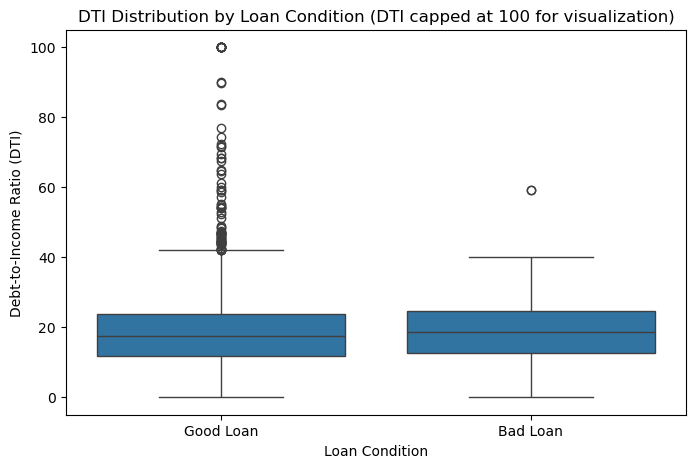

In [52]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="loan_condition",
    y=df["dti"].clip(upper=100),
    data=df
)
plt.title("DTI Distribution by Loan Condition (DTI capped at 100 for visualization)")
plt.xlabel("Loan Condition")
plt.ylabel("Debt-to-Income Ratio (DTI)")
plt.show()


### Loan Amount vs Loan Condition

Loan amount reflects the borrower’s exposure size.
Higher loan amounts may increase default risk if not supported by income.

In this section, we analyze:
- Distribution of loan amounts
- Differences between Good Loans and Bad Loans


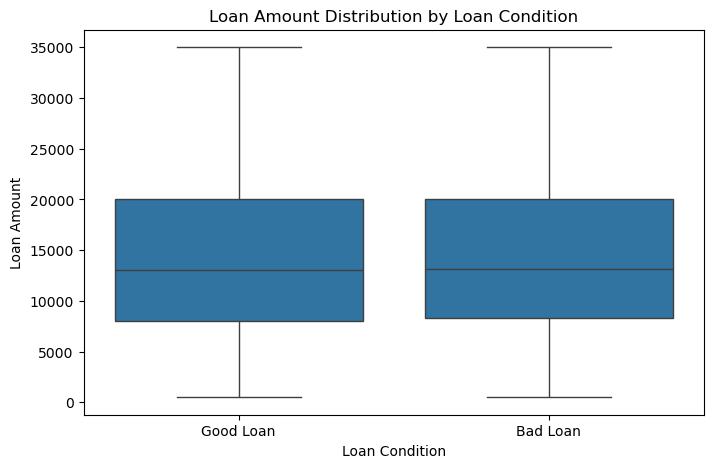

In [53]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="loan_condition",
    y="loan_amount",
    data=df
)
plt.title("Loan Amount Distribution by Loan Condition")
plt.xlabel("Loan Condition")
plt.ylabel("Loan Amount")
plt.show()


### Observations

- Bad Loans show a slightly higher median loan amount
- Upper range of loan amounts is broader for Bad Loans
- Distribution overlap exists, but higher exposure appears riskier

Business intuition:
- Larger loans amplify loss given default
- Loan amount is a critical risk driver


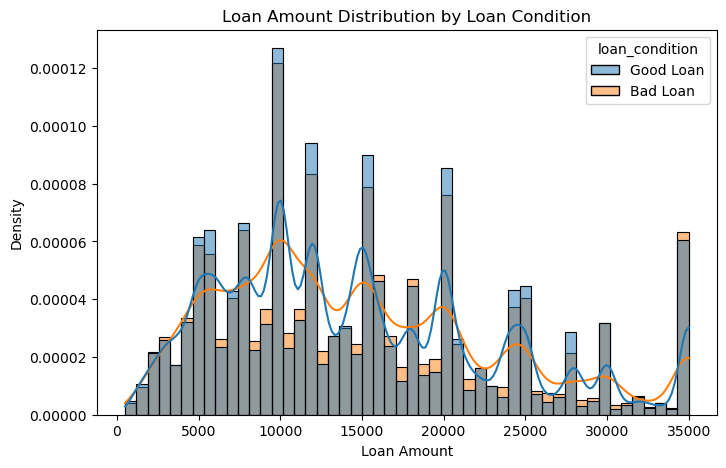

In [54]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="loan_amount",
    hue="loan_condition",
    bins=50,
    kde=True,
    stat="density",
    common_norm=False
)
plt.title("Loan Amount Distribution by Loan Condition")
plt.xlabel("Loan Amount")
plt.ylabel("Density")
plt.show()


### Why Boxplot + Histogram?

- Boxplot → compares medians, spread, outliers
- Histogram → shows full distribution overlap and density

Repeating analysis using different visuals is intentional,
not redundant.


### Annual Income vs Loan Condition

Annual income indicates the borrower’s repayment capacity.
Lower income levels are generally associated with higher default risk.

In this section, we analyze:
- Income distribution by loan condition
- Whether bad loans cluster at lower income ranges


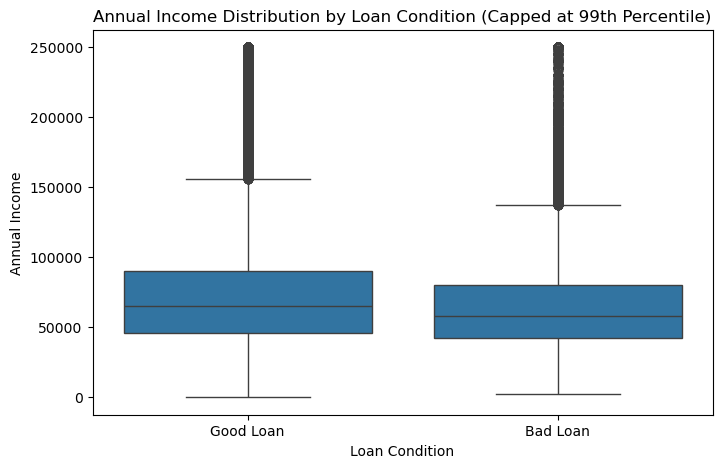

In [55]:
income_cap = df["annual_inc"].quantile(0.99)

plt.figure(figsize=(8, 5))
sns.boxplot(
    x="loan_condition",
    y=df["annual_inc"].clip(upper=income_cap),
    data=df
)
plt.title("Annual Income Distribution by Loan Condition (Capped at 99th Percentile)")
plt.xlabel("Loan Condition")
plt.ylabel("Annual Income")
plt.show()


### Observations

- Good Loans show a higher median annual income
- Bad Loans are more concentrated at lower income levels
- Income variability is higher for Good Loans

Business insight:
- Higher income improves repayment resilience
- Annual income is a strong protective factor


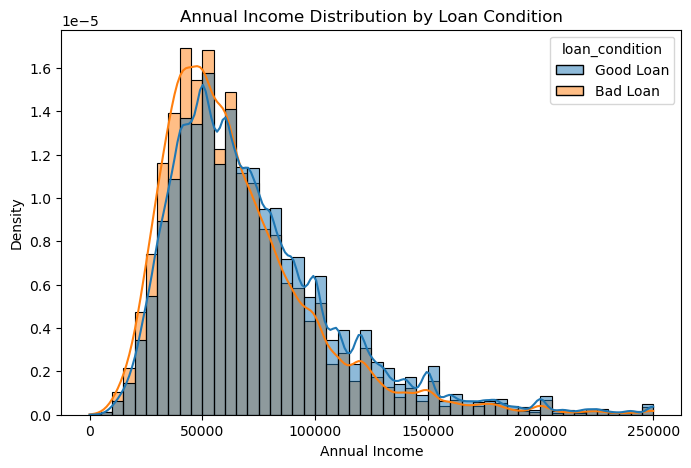

In [56]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df[df["annual_inc"] <= income_cap],
    x="annual_inc",
    hue="loan_condition",
    bins=50,
    kde=True,
    stat="density",
    common_norm=False
)
plt.title("Annual Income Distribution by Loan Condition")
plt.xlabel("Annual Income")
plt.ylabel("Density")
plt.show()


### Key Takeaway

- Lower income borrowers exhibit higher default frequency
- Income complements DTI:
  - DTI → burden
  - Income → capacity

Both should be modeled together.


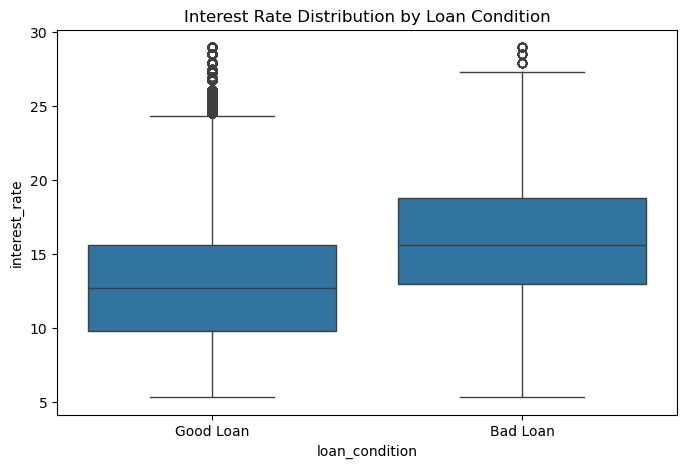

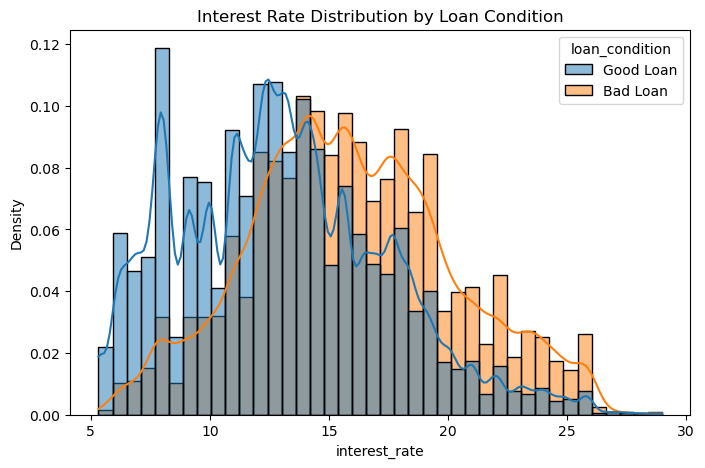

In [57]:
# Cell [45]: Interest Rate vs Loan Condition

plt.figure(figsize=(8, 5))
sns.boxplot(
    x="loan_condition",
    y="interest_rate",
    data=df
)
plt.title("Interest Rate Distribution by Loan Condition")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="interest_rate",
    hue="loan_condition",
    bins=40,
    kde=True,
    stat="density",
    common_norm=False
)
plt.title("Interest Rate Distribution by Loan Condition")
plt.show()


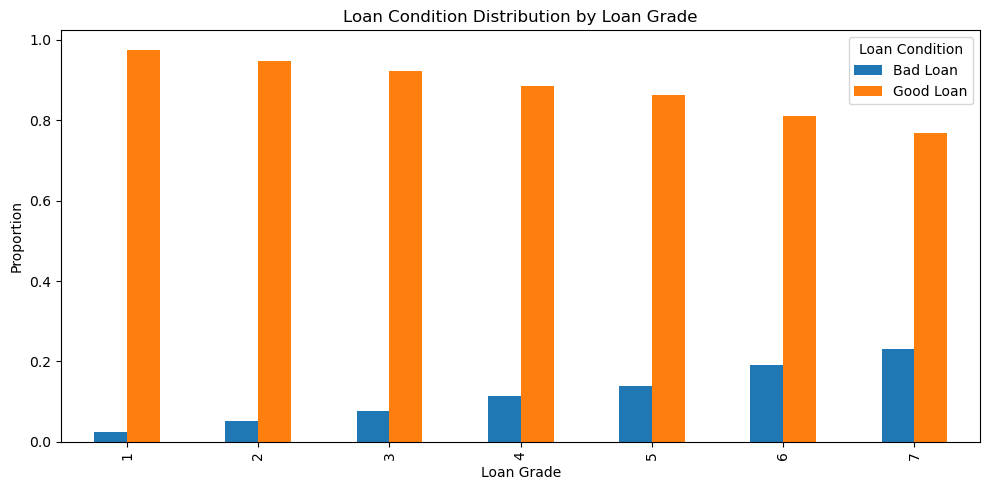

In [58]:
# Cell [46]: Loan Grade vs Loan Condition (Normalized)

grade_ct = pd.crosstab(
    df["grade_cat"],
    df["loan_condition"],
    normalize="index"
)

grade_ct.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Loan Condition Distribution by Loan Grade")
plt.ylabel("Proportion")
plt.xlabel("Loan Grade")
plt.legend(title="Loan Condition")
plt.tight_layout()
plt.show()


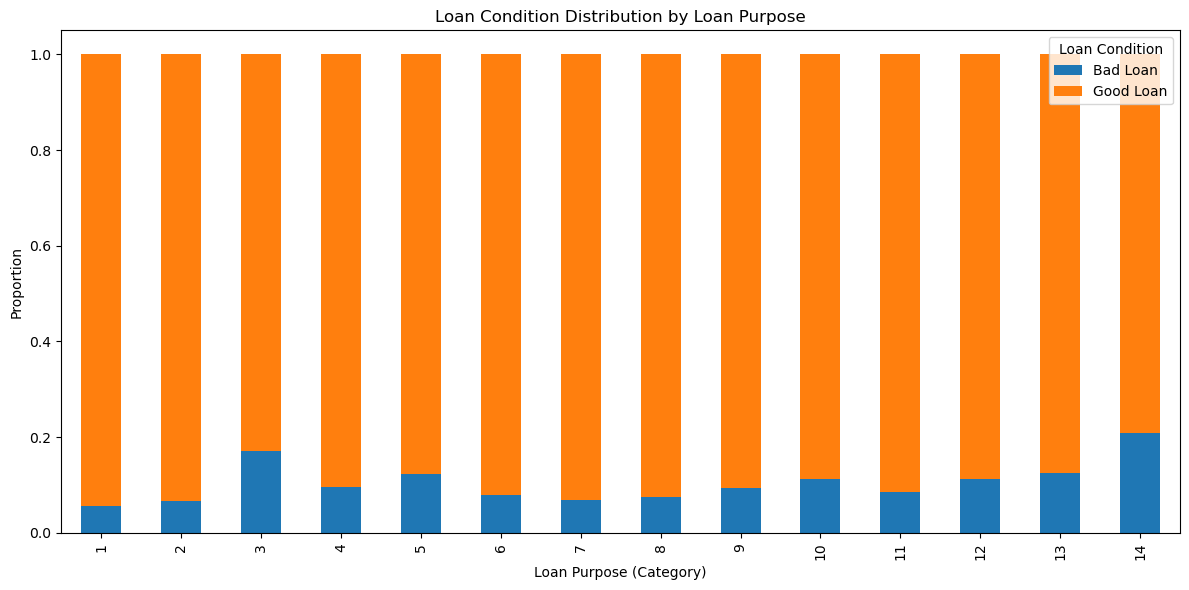

In [59]:
# Cell [46]: Loan Purpose vs Loan Condition (Normalized)

purpose_ct = (
    df.groupby(["purpose_cat", "loan_condition"])
      .size()
      .unstack()
)

# Normalize row-wise
purpose_ct_norm = purpose_ct.div(purpose_ct.sum(axis=1), axis=0)

purpose_ct_norm.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Loan Condition Distribution by Loan Purpose")
plt.xlabel("Loan Purpose (Category)")
plt.ylabel("Proportion")
plt.legend(title="Loan Condition")
plt.tight_layout()
plt.show()


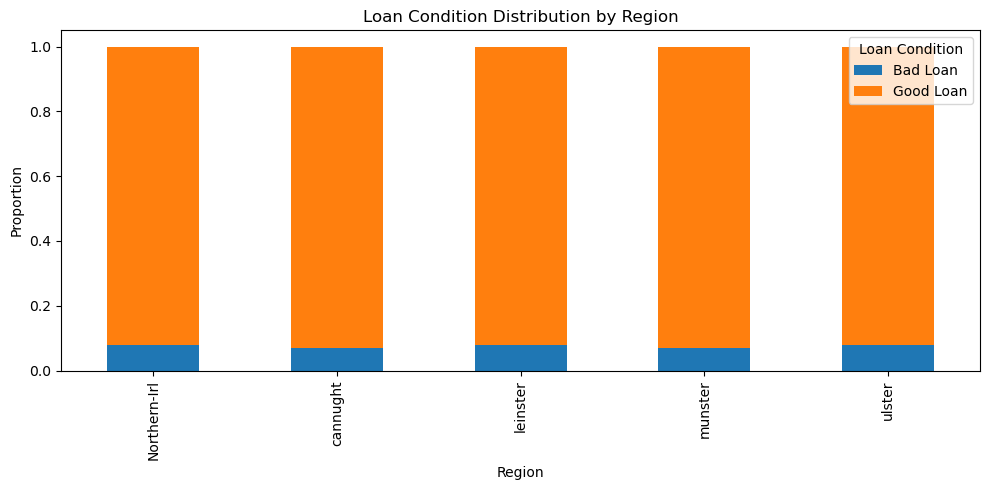

In [60]:
# Cell [47]: Region vs Loan Condition (Normalized)

region_ct = (
    df.groupby(["region", "loan_condition"])
      .size()
      .unstack()
)

# Normalize row-wise
region_ct_norm = region_ct.div(region_ct.sum(axis=1), axis=0)

region_ct_norm.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.title("Loan Condition Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Proportion")
plt.legend(title="Loan Condition")
plt.tight_layout()
plt.show()


### Key EDA Takeaways

Based on exploratory analysis:

- The target variable (`loan_condition`) is highly imbalanced (~7.6% Bad Loans).
- Strong predictors of Bad Loans include:
  - Higher interest rates
  - Lower loan grades
  - Higher debt-to-income ratios (DTI)
- Moderate signal observed from:
  - Loan purpose
  - Loan amount
  - Annual income (with heavy right skew)
- Minimal to no signal observed from:
  - Region

These findings guide the modeling strategy:
- Use evaluation metrics robust to class imbalance (ROC-AUC, Recall, Precision-Recall).
- Prefer models capable of capturing non-linear relationships.
- Consider class imbalance handling during training.


In [62]:
# Save cleaned dataset for downstream notebooks
df.to_csv("data/loan_cleaned.csv", index=False)
